<a href="https://colab.research.google.com/github/Saransh-Basu-01/50-Ml-Projects-to-understand-LLMs/blob/main/Project_4_Token_Lengths_in_characters_and_bytes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [39]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import matplotlib as mpl

# Demo of Counting bytes

In [3]:
things = [ 'x','!','ü','🥰','活' ]

for t in things:
  print(f"{len(t.encode('utf-8'))} bytes in {t}")

1 bytes in x
1 bytes in !
2 bytes in ü
4 bytes in 🥰
3 bytes in 活


# Part_1:Character vs byte lengths in all tokens

## Task_1:
- Import the GPT-2 tokenizer. Loop through all tokens in the tok
enizer’s vocab, and count the number of characters and the number
of bytes in each token. Then depict the results in a scatter plot as in
Figure 2.11. The x-y coordinate pairs correspond to the unique pairs
of character lengths and byte lengths, and the color of each marker
corresponds to the log-frequency of that pair occurring in the vocab.

In [1]:
from transformers import AutoTokenizer
tokenizer=AutoTokenizer.from_pretrained('gpt2')

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

In [4]:
token_lens=np.zeros((200,200),dtype=int)

In [7]:
token_lens

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])

In [8]:
tokenizer.vocab_size

50257

In [9]:
token_len_char=np.zeros(tokenizer.vocab_size,dtype=int)

In [11]:
token_len_char.shape

(50257,)

In [12]:
token_len_byte=np.zeros(tokenizer.vocab_size,dtype=int)

In [28]:
for i in range(tokenizer.vocab_size):
  thistoken=tokenizer.decode([i])
  token_len_char[i]=len(thistoken)
  token_len_byte[i]=len(thistoken.encode('utf-8'))
  token_lens[token_len_char[i],token_len_byte[i]] += 1



In [38]:
token_lens[5][5]

np.int64(7286)

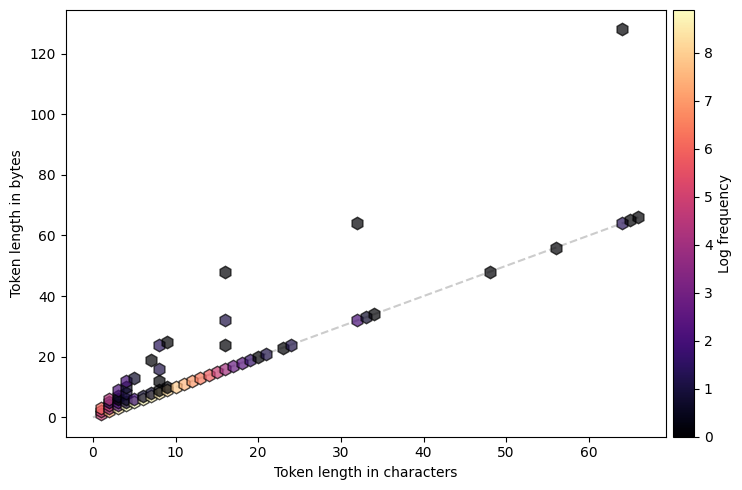

In [40]:
fig=plt.figure(figsize=(8,5))
norm=mpl.colors.Normalize(vmin=0,vmax=np.log(token_lens.max()))
x,y=np.nonzero(token_lens)
for xi,yi in zip(x,y):
  plt.plot(xi,yi,'kh',alpha=.7,markersize=9,
           markerfacecolor=plt.cm.magma(norm(np.log(token_lens[xi,yi]))))

sm = mpl.cm.ScalarMappable(cmap=mpl.cm.magma,norm=norm)
cbar = plt.colorbar(sm,ax=fig.gca(),pad=.01)
cbar.set_label('Log frequency')
plt.plot([0,xi],[0,xi],'--',color=[.8,.8,.8],zorder=-100)

# prettify the plot
plt.gca().set(xlabel='Token length in characters',
              ylabel='Token length in bytes')

plt.tight_layout()
plt.show()


## Task_2
- Find the tokens that have a mismatch between character and byte
count. You should find 873 tokens with mismatching lengths. Print
out 30 randomly selected tokens separated by a pipe symbol (the
vertical line). Figure 2.12 shows a random subset

In [48]:
noteq = np.where(token_len_char != token_len_byte)[0]
print(f'There are {len(noteq)} tokens with unequal lengths.\nHere are 30:\n')

for idx in noteq[np.random.randint(0,len(noteq),30)]:
  print(f'{tokenizer.decode([idx])} | ',end='')

There are 873 tokens with unequal lengths.
Here are 30:

�� | �� | τ | .� | р | َ | •• | е | � | � | و | � | � | � | ン | к | ¯¯¯¯ |          | � | ב | � | ———— | ��� | ヴァ | 将 | て | � | 、 |  � | ク | 

In [49]:
for idx in noteq:
  print(tokenizer.decode([idx]))

�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
 �
 –
 —
—
�
…
 �
�
 
–
 �
�
é
•
­
 …
��
�
 £
——
  
・
�
�
¯
¯¯
Â
 �
 •
  
の
Ã
ÃÂ
ÃÂÃÂ
 �
ー
��
 ±
��
 裏
ン
�
á
��
°
─
 �
……
®
��
█
™
————
──
 §
�
    
í
ス
��
¯¯¯¯
ö
ü
·
 Poké
ル
ラ
‐
ÃÂÃÂÃÂÃÂ
​
 −
 Pokémon
…"
██
ó
ā
��
 �
�
 €
 �
 ©
 �
ä
イ
    
….
�
��
ア
龍
�
ー�
����
″
 �
 �
ñ
リ
�
×
ا
ō
ト
 �
 �
 »
.—
「
」
ド
�
ل
��
 ×
è
−
ク
 ·
 �
 �
 �
ッ
ÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂ
————————
£
 �
о
 →
¯¯¯¯¯¯¯¯
"—
神
の�
★
シ
…………
�
────
а
ウ
ç
©
ロ
 �
§
ィ
。
е
�
�
α
 �
′
 �
フ
の�
»
�
 �
        
ゴ
�
�
 �
´
��
い
�
士
ón
и
 �
 μ
 �
ī
�
龍�
—"
ドラ
 │
�
�
�
�
�
マ
 ​
 裏�
ū
т
████
オ
 �
 �
魔
és
‑
�
ジ
 ―
 «
án
р
æ
��
ú
的
…]
人
с
カ
デ
 ­
 °
░
ée
ん
н
し
±
�
ي
        
�
�醒
••
�
�
â
ゴン
 (£
ÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂ
ャ
½
 █
 �
��
ن
ヘ
タ
、
ال
エ
��
覚醒
�
ガ
 �
 […]
�
 ★
ブ
ø
レ
�
à
«
َ
テ
 ‎
"…

# Part_2:Visualizing Token lengths

## Task_1
- Write code to produce Figure 2.13. This figure shows the token length
on the y-axis, as a function of the token index on the x-axis, for
characters and for bytes.

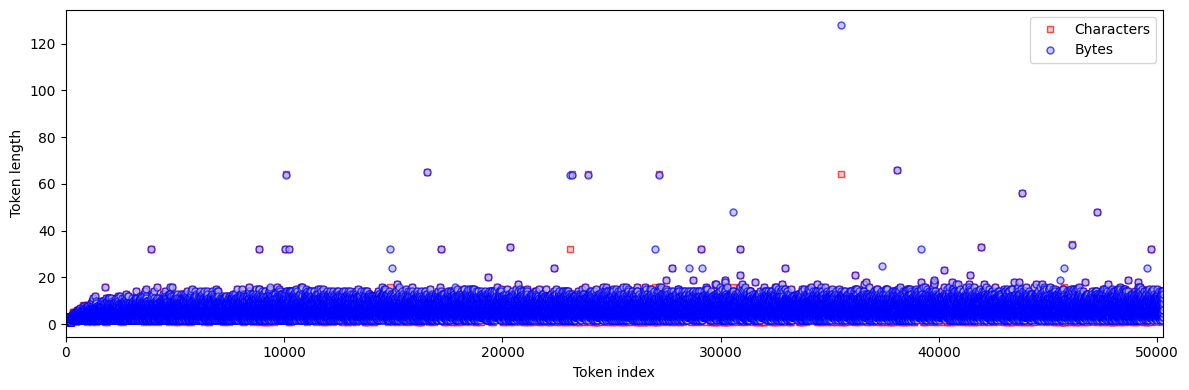

In [61]:

plt.figure(figsize=(12,4))

# use for plotting only the first N tokens
max2plot = tokenizer.vocab_size #600

# note: I added a small y-axis offset to help visualize discrepancies
plt.plot(token_len_char[:max2plot]+.1,'rs',label='Characters',markerfacecolor=[.9,.7,.7,.7],markersize=5)
plt.plot(token_len_byte[:max2plot],'bo',label='Bytes',markerfacecolor=[.7,.7,.9,.7],markersize=5)

plt.legend()
plt.gca().set(xlabel='Token index',ylabel='Token length',xlim=[-10,max2plot+10])

plt.tight_layout()
plt.show()

In [53]:
max2plot = tokenizer.vocab_size
max2plot

50257

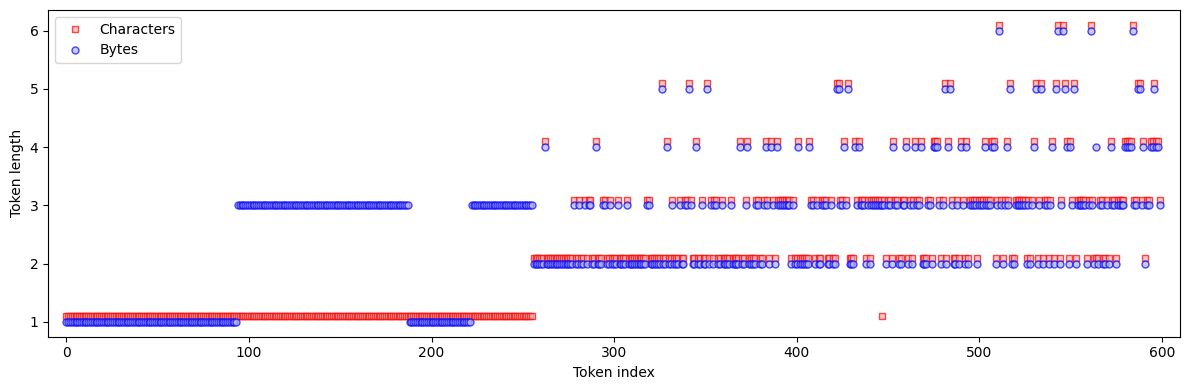

In [64]:
plt.figure(figsize=(12,4))

# use for plotting only the first N tokens
max2plot=600 #600

# note: I added a small y-axis offset to help visualize discrepancies
plt.plot(token_len_char[:max2plot]+.1,'rs',label='Characters',markerfacecolor=[.9,.7,.7,.7],markersize=5)
plt.plot(token_len_byte[:max2plot],'bo',label='Bytes',markerfacecolor=[.7,.7,.9,.7],markersize=5)

plt.legend()
plt.gca().set(xlabel='Token index',ylabel='Token length',xlim=[-10,max2plot+10])

plt.tight_layout()
plt.show()

# Part_3:Finding the mismatch length tokens

## Task_1:
- Write code to create Figure 2.14. Each token index has a small circle
plotted at y = 0 (same number of characters as bytes) or y = 1 (more
bytes than characters). Add small random jitters to help visualize
the density of dots

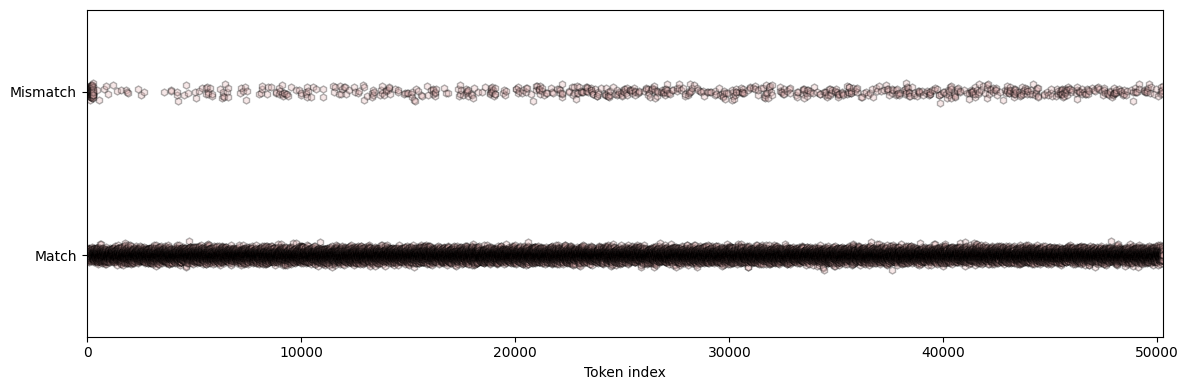

In [65]:
plt.figure(figsize=(12,4))

# y-values are 0 or 1, depending on match
yVals = (token_len_char!=token_len_byte).astype(float)
yVals += np.random.normal(0,.02,len(yVals))

# Not in the instructions, but also interesting to plot the discrepancy counts
#yVals = token_lens_bytes - token_lens_chars

# plot them
plt.plot(yVals,'kh',markerfacecolor=[.9,.7,.7,.3],markersize=5)

# and make the axis look nicer
plt.gca().set(xlabel='Token index',ylim=[-.5,1.5],xlim=[-30,tokenizer.vocab_size+30],
              yticks=[0,1],yticklabels=['Match','Mismatch'])

plt.tight_layout()
plt.show()

# Part_4:Length Distributions

## Task_1:
- Use np.unique to calculate the unique number of characters and
bytes in the tokenizer, using the variables you created in Part 1.
Convert the counts to percent and plot the results as in Figure 2.15.

In [70]:
np.unique(token_len_byte)

array([  1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,  13,
        14,  15,  16,  17,  18,  19,  20,  21,  23,  24,  25,  32,  33,
        34,  48,  56,  64,  65,  66, 128])

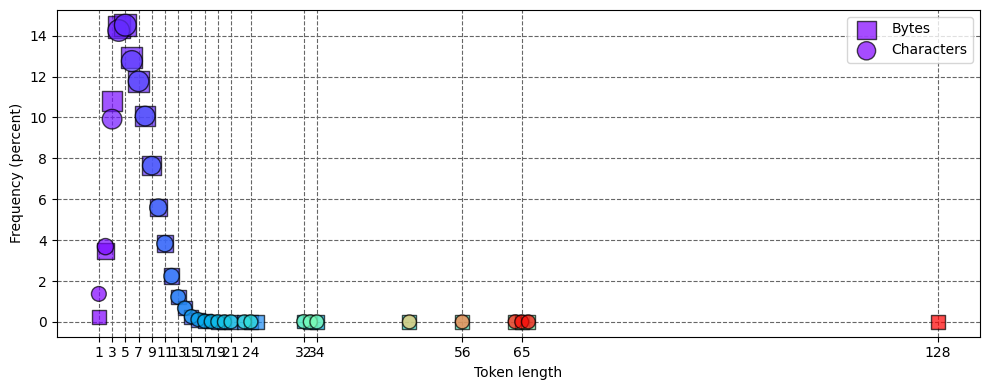

In [71]:
xB,yB = np.unique(token_len_byte,return_counts=True)
yB = 100*yB / yB.sum()

xC,yC = np.unique(token_len_char,return_counts=True)
yC = 100*yC / yC.sum()

# draw
plt.figure(figsize=(10,4))
plt.scatter(xB,yB,100+yB*10,c=xB,alpha=.7,cmap='rainbow',edgecolor='k',marker='s',label='Bytes')
plt.scatter(xC,yC,100+yC*10,c=xC,alpha=.7,cmap='rainbow',edgecolor='k',marker='o',label='Characters')

plt.gca().set(xlabel='Token length',xticks=xB[::2],ylabel='Frequency (percent)')
plt.grid(color=[.4,.4,.4],linestyle='--')
plt.gca().set_axisbelow(True)
plt.legend()

plt.tight_layout()
plt.show()

In [66]:
xB,yB = np.unique(token_len_byte,return_counts=True)

In [67]:
xB,yB

(array([  1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,  13,
         14,  15,  16,  17,  18,  19,  20,  21,  23,  24,  25,  32,  33,
         34,  48,  56,  64,  65,  66, 128]),
 array([ 128, 1742, 5440, 7254, 7301, 6496, 5914, 5055, 3848, 2813, 1924,
        1133,  614,  336,  129,   58,   16,   11,    6,    1,    3,    1,
           8,    1,   11,    2,    1,    2,    1,    5,    1,    1,    1]))

In [68]:
xC,yC = np.unique(token_len_char,return_counts=True)
xC,yC

(array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
        18, 19, 20, 21, 23, 24, 32, 33, 34, 48, 56, 64, 65, 66]),
 array([ 688, 1850, 4983, 7162, 7294, 6410, 5913, 5059, 3841, 2810, 1924,
        1125,  612,  336,  129,   60,   16,   11,    5,    1,    3,    1,
           3,    9,    2,    1,    1,    1,    5,    1,    1]))

In [72]:
# Find all tokens that have exactly 128 bytes
tokens_with_128_bytes = []
for i in range(tokenizer.vocab_size):
    if token_len_byte[i] == 128:
        tokens_with_128_bytes.append(i)

# Print results
print(f"Found {len(tokens_with_128_bytes)} tokens with 128 bytes:")
for idx in tokens_with_128_bytes[:10]:  # Show first 10
    token_text = tokenizer.decode([idx])
    char_len = token_len_char[idx]
    byte_len = token_len_byte[idx]
    print(f"Token #{idx}: '{token_text}' - {char_len} chars, {byte_len} bytes")

Found 1 tokens with 128 bytes:
Token #35496: 'ÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂ' - 64 chars, 128 bytes


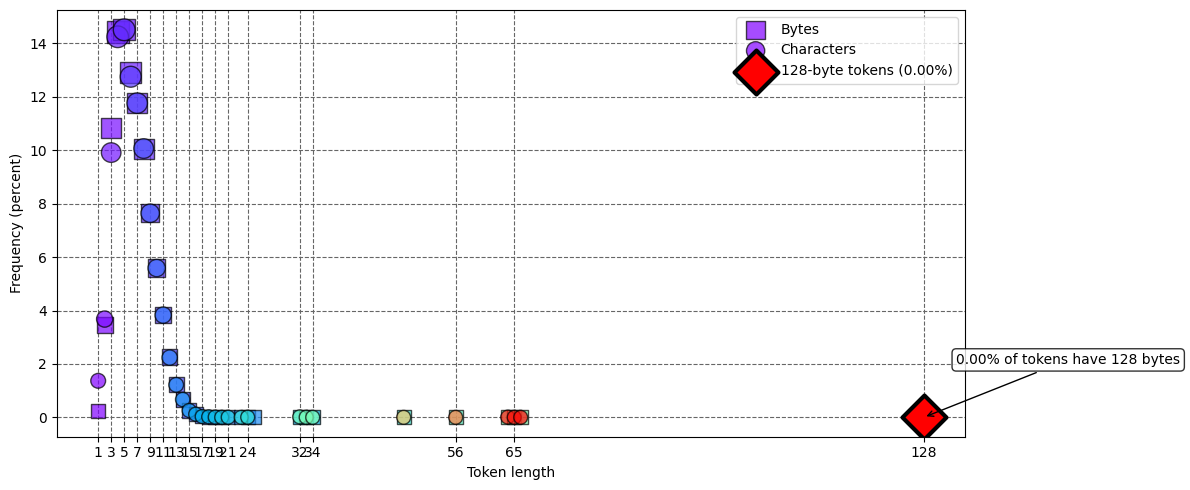

In [73]:
plt.figure(figsize=(12, 5))

# Original scatter plots
xB, yB = np.unique(token_len_byte, return_counts=True)
yB = 100 * yB / yB.sum()

xC, yC = np.unique(token_len_char, return_counts=True)
yC = 100 * yC / yC.sum()

# Plot the original data
plt.scatter(xB, yB, 100+yB*10, c=xB, alpha=.7, cmap='rainbow',
           edgecolor='k', marker='s', label='Bytes')
plt.scatter(xC, yC, 100+yC*10, c=xC, alpha=.7, cmap='rainbow',
           edgecolor='k', marker='o', label='Characters')

# Highlight the point at x=128 (if it exists)
if 128 in xB:
    idx_128 = np.where(xB == 128)[0][0]
    plt.scatter(128, yB[idx_128], 500, c='red', alpha=1.0,
               edgecolor='black', linewidth=3, marker='D',
               label=f'128-byte tokens ({yB[idx_128]:.2f}%)')
    # Add annotation
    plt.annotate(f'{yB[idx_128]:.2f}% of tokens have 128 bytes',
                xy=(128, yB[idx_128]),
                xytext=(128 + 5, yB[idx_128] + 2),
                arrowprops=dict(arrowstyle='->', color='black'),
                fontsize=10, bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
else:
    print("No tokens with exactly 128 bytes found!")

plt.gca().set(xlabel='Token length', xticks=xB[::2], ylabel='Frequency (percent)')
plt.grid(color=[.4,.4,.4], linestyle='--')
plt.gca().set_axisbelow(True)
plt.legend()
plt.tight_layout()
plt.show()

In [77]:
tokenizer.decode(np.argmax(token_len_byte))
tokenizer.decode(np.argmax(token_len_char))

' ================================================================='